In [3]:
from pathlib import Path
import json
import hashlib
import json
import math
import pickle
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
from sklearn.covariance import MinCovDet
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import auc, precision_recall_curve, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def resolve_project_root():
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists():
            return candidate
    return start


project_root = resolve_project_root()
data_dir = project_root / "data"
raw_dir = data_dir / "raw"
interim_dir = data_dir / "interim"
metadata_dir = data_dir / "metadata"
processed_dir = data_dir / "processed"
models_dir = project_root / "models"
reports_dir = project_root / "reports"
tables_dir = reports_dir / "tables"
figures_dir = reports_dir / "figures"

for folder in [raw_dir, interim_dir, metadata_dir, processed_dir, models_dir, reports_dir, tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Raw data directory: {raw_dir}")


Project root: /home/hamza/Documents/research/aero-res/aircraft_fault_localization
Raw data directory: /home/hamza/Documents/research/aero-res/aircraft_fault_localization/data/raw


In [4]:
def classify_group(path):
    folder = path.parent.name.lower()
    name = path.name.lower()
    if any(token in folder or token in name for token in ["healthy", "normal", "reference"]):
        return "healthy"
    if any(token in folder or token in name for token in ["defective", "defected", "defect", "fault", "failed"]):
        return "defective"
    return "unassigned"


def file_sha256(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()


def normalize_columns(columns):
    normalized = []
    for value in columns:
        text = "" if pd.isna(value) else str(value).strip().lower()
        text = re.sub(r"\s+", "_", text)
        text = re.sub(r"[^a-z0-9_]+", "", text)
        text = re.sub(r"_+", "_", text).strip("_")
        normalized.append(text if text else "unnamed")
    seen = {}
    output = []
    for name in normalized:
        seen[name] = seen.get(name, 0) + 1
        output.append(name if seen[name] == 1 else f"{name}_{seen[name]}")
    return output


def inspect_workbook(path):
    rows = []
    try:
        workbook = openpyxl.load_workbook(path, read_only=True, data_only=True)
        for sheet_name in workbook.sheetnames:
            worksheet = workbook[sheet_name]
            rows.append(
                {
                    "file_name": path.name,
                    "relative_path": str(path.relative_to(project_root)),
                    "sheet_name": sheet_name,
                    "max_row": int(worksheet.max_row or 0),
                    "max_column": int(worksheet.max_column or 0),
                    "error": None,
                }
            )
        workbook.close()
    except Exception as exc:
        rows.append(
            {
                "file_name": path.name,
                "relative_path": str(path.relative_to(project_root)),
                "sheet_name": None,
                "max_row": np.nan,
                "max_column": np.nan,
                "error": str(exc),
            }
        )
    return rows


def choose_sheet(path, sheet_inventory):
    subset = sheet_inventory.loc[sheet_inventory["relative_path"].eq(str(path.relative_to(project_root)))].copy()
    subset["area"] = pd.to_numeric(subset["max_row"], errors="coerce").fillna(0) * pd.to_numeric(subset["max_column"], errors="coerce").fillna(0)
    subset = subset.sort_values(["area", "max_row", "max_column"], ascending=False)
    if len(subset) and pd.notna(subset.iloc[0]["sheet_name"]):
        return subset.iloc[0]["sheet_name"]
    with pd.ExcelFile(path, engine="openpyxl") as excel_file:
        return excel_file.sheet_names[0]


def choose_header_from_preview(preview):
    preview = preview.dropna(axis=0, how="all").dropna(axis=1, how="all")
    if preview.empty:
        return 0
    best_row = 0
    best_score = -np.inf
    limit = min(12, len(preview))
    for row_index in range(limit):
        values = preview.iloc[row_index].tolist()
        columns = normalize_columns(values)
        named = sum(not str(column).startswith("unnamed") for column in columns)
        unique = len(set(columns))
        below = preview.iloc[row_index + 1 : min(len(preview), row_index + 8)]
        numeric_density = 0.0
        if len(below):
            numeric_density = below.apply(lambda column: pd.to_numeric(column, errors="coerce").notna().mean()).mean()
        score = named + unique * 0.25 + float(numeric_density) * len(columns)
        if score > best_score:
            best_score = score
            best_row = row_index
    return int(best_row)


def read_flight_frame(path, sheet_name):
    with pd.ExcelFile(path, engine="openpyxl") as excel_file:
        preview = pd.read_excel(excel_file, sheet_name=sheet_name, header=None, nrows=16)
        header = choose_header_from_preview(preview)
        frame = pd.read_excel(excel_file, sheet_name=sheet_name, header=header)
    frame = frame.dropna(axis=0, how="all").dropna(axis=1, how="all")
    frame.columns = normalize_columns(frame.columns)
    frame = frame.reset_index(drop=True)
    return frame, header


def is_excluded_feature(name):
    text = str(name).lower()
    patterns = ["time", "timestamp", "date", "label", "target", "fault", "defect", "class", "unnamed", "index", "row", "sequence", "file", "path", "sheet"]
    if text in {"id", "sr", "sno", "serial", "sample", "samples"}:
        return True
    return any(pattern in text for pattern in patterns)


def numeric_profile(frame, file_name, group):
    rows = []
    for column in frame.columns:
        if is_excluded_feature(column):
            continue
        series = pd.to_numeric(frame[column], errors="coerce")
        non_null_ratio = float(series.notna().mean()) if len(series) else 0.0
        unique_values = int(series.nunique(dropna=True))
        if non_null_ratio >= 0.10 and unique_values >= 2:
            rows.append(
                {
                    "file_name": file_name,
                    "group": group,
                    "feature": column,
                    "non_null_ratio": non_null_ratio,
                    "unique_values": unique_values,
                    "mean": float(series.mean()) if series.notna().any() else np.nan,
                    "std": float(series.std()) if series.notna().sum() > 1 else np.nan,
                    "min": float(series.min()) if series.notna().any() else np.nan,
                    "max": float(series.max()) if series.notna().any() else np.nan,
                }
            )
    return rows


def safe_to_parquet(frame, path):
    try:
        frame.to_parquet(path, index=False)
        return str(path)
    except Exception:
        fallback = path.with_suffix(".csv")
        frame.to_csv(fallback, index=False)
        return str(fallback)


In [5]:
xlsx_files = sorted(path for path in raw_dir.rglob("*.xlsx") if path.is_file() and not path.name.startswith("~$"))
if not xlsx_files:
    raise FileNotFoundError(f"No Excel files were found under {raw_dir}. Place the raw aircraft Excel files in data/raw and rerun this notebook.")

inventory = pd.DataFrame(
    [
        {
            "file_name": path.name,
            "relative_path": str(path.relative_to(project_root)),
            "folder": path.parent.name,
            "group": classify_group(path),
            "size_bytes": int(path.stat().st_size),
            "sha256": file_sha256(path),
        }
        for path in xlsx_files
    ]
)

sheet_inventory = pd.DataFrame([row for path in xlsx_files for row in inspect_workbook(path)])
inventory.to_csv(metadata_dir / "file_inventory.csv", index=False)
sheet_inventory.to_csv(metadata_dir / "sheet_inventory.csv", index=False)

dataset_profile = (
    inventory.groupby(["group", "folder"], as_index=False)
    .agg(files=("file_name", "nunique"), total_size_bytes=("size_bytes", "sum"))
    .sort_values(["group", "folder"])
)
dataset_profile.to_csv(metadata_dir / "dataset_profile.csv", index=False)
display(dataset_profile)


,group,folder,files,total_size_bytes
0,defective,defective,15,596079229
1,healthy,healthy,9,626706039
2,healthy,reference,13,638365650


In [6]:
working_files = inventory.loc[inventory["group"].isin(["healthy", "defective"])].copy().reset_index(drop=True)
if working_files["group"].nunique() < 2:
    raise ValueError("The workflow needs both healthy and defective Excel files.")

loaded_frames = []
reading_profiles = []
feature_profile_rows = []

for row in working_files.itertuples(index=False):
    path = project_root / row.relative_path
    try:
        sheet_name = choose_sheet(path, sheet_inventory)
        frame, header_row = read_flight_frame(path, sheet_name)
        feature_profile_rows.extend(numeric_profile(frame, row.file_name, row.group))
        loaded_frames.append(
            {
                "file_name": row.file_name,
                "relative_path": row.relative_path,
                "group": row.group,
                "sheet_name": sheet_name,
                "header_row": int(header_row),
                "frame": frame,
            }
        )
        reading_profiles.append(
            {
                "file_name": row.file_name,
                "relative_path": row.relative_path,
                "group": row.group,
                "sheet_name": sheet_name,
                "header_row": int(header_row),
                "rows": int(len(frame)),
                "columns": int(frame.shape[1]),
                "status": "loaded",
                "error": None,
            }
        )
    except Exception as exc:
        reading_profiles.append(
            {
                "file_name": row.file_name,
                "relative_path": row.relative_path,
                "group": row.group,
                "sheet_name": None,
                "header_row": None,
                "rows": 0,
                "columns": 0,
                "status": "failed",
                "error": str(exc),
            }
        )

reading_profile = pd.DataFrame(reading_profiles)
feature_profile = pd.DataFrame(feature_profile_rows)
reading_profile.to_csv(metadata_dir / "reading_profile.csv", index=False)
feature_profile.to_csv(metadata_dir / "numeric_feature_profile.csv", index=False)

if not loaded_frames:
    raise ValueError("No valid Excel frames could be loaded.")

feature_summary = (
    feature_profile.groupby("feature", as_index=False)
    .agg(
        files=("file_name", "nunique"),
        healthy_files=("group", lambda values: int((values == "healthy").sum())),
        defective_files=("group", lambda values: int((values == "defective").sum())),
        median_non_null_ratio=("non_null_ratio", "median"),
        median_unique_values=("unique_values", "median"),
        global_std=("std", "median"),
    )
    .sort_values(["files", "median_non_null_ratio", "median_unique_values"], ascending=False)
)

healthy_file_count = int(working_files.loc[working_files["group"].eq("healthy"), "file_name"].nunique())
defective_file_count = int(working_files.loc[working_files["group"].eq("defective"), "file_name"].nunique())
feature_summary["healthy_file_ratio"] = feature_summary["healthy_files"] / max(healthy_file_count, 1)
feature_summary["defective_file_ratio"] = feature_summary["defective_files"] / max(defective_file_count, 1)
feature_summary["selected_for_anomaly"] = (
    feature_summary["healthy_file_ratio"].ge(0.65)
    & feature_summary["defective_file_ratio"].ge(0.30)
    & feature_summary["median_non_null_ratio"].ge(0.50)
    & feature_summary["global_std"].fillna(0).gt(0)
)

selected_features = feature_summary.loc[feature_summary["selected_for_anomaly"], "feature"].tolist()
if len(selected_features) < 3:
    selected_features = feature_summary.loc[feature_summary["median_non_null_ratio"].ge(0.30), "feature"].head(30).tolist()
if len(selected_features) < 2:
    raise ValueError("Too few stable numeric features were found.")
selected_features = selected_features[:60]
feature_summary.to_csv(metadata_dir / "feature_manifest.csv", index=False)
feature_summary.to_csv(tables_dir / "feature_manifest.csv", index=False)

summary = pd.DataFrame(
    {
        "metric": ["loaded_files", "healthy_files", "defective_files", "selected_features", "loaded_rows"],
        "value": [
            len(loaded_frames),
            healthy_file_count,
            defective_file_count,
            len(selected_features),
            int(sum(len(item["frame"]) for item in loaded_frames)),
        ],
    }
)
summary.to_csv(tables_dir / "anomaly_dataset_summary.csv", index=False)
display(summary)


,metric,value
0,loaded_files,37
1,healthy_files,22
2,defective_files,15
3,selected_features,60
4,loaded_rows,524149


In [7]:
standardized_parts = []
for item in loaded_frames:
    frame = item["frame"].copy()
    for feature in selected_features:
        if feature not in frame.columns:
            frame[feature] = np.nan
    part = frame[selected_features].apply(pd.to_numeric, errors="coerce")
    part.insert(0, "original_row_index", np.arange(len(part), dtype=np.int64))
    part.insert(0, "sequence_index", np.arange(len(part), dtype=np.int64))
    part.insert(0, "sheet_name", item["sheet_name"])
    part.insert(0, "group", item["group"])
    part.insert(0, "relative_path", item["relative_path"])
    part.insert(0, "file_name", item["file_name"])
    standardized_parts.append(part)

standardized_df = pd.concat(standardized_parts, ignore_index=True)
standardized_df[selected_features] = standardized_df[selected_features].astype("float32")
standardized_path = processed_dir / "flight_rows_standardized.parquet"
written_standardized_path = safe_to_parquet(standardized_df, standardized_path)
standardized_df.to_csv(processed_dir / "flight_rows_standardized_preview.csv", index=False)

missingness = standardized_df.groupby("group")[selected_features].apply(lambda frame: frame.isna().mean()).T.reset_index().rename(columns={"index": "feature"})
missingness.to_csv(tables_dir / "feature_missingness_by_group.csv", index=False)

file_row_summary = standardized_df.groupby(["file_name", "group"], as_index=False).agg(rows=("file_name", "size"))
file_row_summary.to_csv(tables_dir / "file_row_summary.csv", index=False)
print(f"Saved standardized dataset: {written_standardized_path}")
display(file_row_summary.head(20))


Saved standardized dataset: /home/hamza/Documents/research/aero-res/aircraft_fault_localization/data/processed/flight_rows_standardized.parquet


,file_name,group,rows
0,00100726.xlsx,healthy,12463
1,00101206.xlsx,healthy,19981
2,002.xlsx,healthy,19119
3,003.xlsx,healthy,19176
4,01007.xlsx,healthy,19620
5,01008.xlsx,healthy,11599
6,01009.xlsx,healthy,11723
7,01010.xlsx,healthy,18263
8,01011.xlsx,healthy,19127
9,01012.xlsx,healthy,19982


In [8]:
def split_healthy_files(healthy_files):
    healthy_files = np.array(sorted(healthy_files))
    if len(healthy_files) < 3:
        return healthy_files.tolist(), healthy_files.tolist()
    dummy_x = pd.DataFrame({"file_name": healthy_files})
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
    train_index, validation_index = next(splitter.split(dummy_x, groups=healthy_files))
    return healthy_files[train_index].tolist(), healthy_files[validation_index].tolist()


def robust_component(value, center, scale):
    scale = float(scale) if float(scale) > 1e-12 else 1.0
    return np.clip((value - center) / scale, 0, None)


healthy_files = standardized_df.loc[standardized_df["group"].eq("healthy"), "file_name"].unique().tolist()
healthy_train_files, healthy_validation_files = split_healthy_files(healthy_files)
train_mask = standardized_df["file_name"].isin(healthy_train_files) & standardized_df["group"].eq("healthy")
healthy_reference = standardized_df.loc[train_mask, selected_features].copy()
if len(healthy_reference) < 20:
    healthy_reference = standardized_df.loc[standardized_df["group"].eq("healthy"), selected_features].copy()

feature_medians = healthy_reference.median(numeric_only=True)
analysis_matrix = standardized_df[selected_features].fillna(feature_medians).fillna(0).astype("float32")
healthy_matrix = healthy_reference.fillna(feature_medians).fillna(0).astype("float32")

scaler = RobustScaler(quantile_range=(10, 90), unit_variance=False)
scaler.fit(healthy_matrix)
healthy_scaled = scaler.transform(healthy_matrix)
all_scaled = scaler.transform(analysis_matrix)

candidate_components = min(len(selected_features), max(2, min(24, int(np.ceil(np.sqrt(len(selected_features)) * 4)))))
initial_pca = PCA(n_components=min(candidate_components, len(selected_features)), random_state=RANDOM_STATE)
initial_pca.fit(healthy_scaled)
cumulative_variance = np.cumsum(initial_pca.explained_variance_ratio_)
n_components = int(np.searchsorted(cumulative_variance, 0.95) + 1)
n_components = int(np.clip(n_components, 2, min(candidate_components, len(selected_features))))
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
pca.fit(healthy_scaled)

healthy_pca = pca.transform(healthy_scaled)
all_pca = pca.transform(all_scaled)
all_reconstruction = pca.inverse_transform(all_pca)
pca_reconstruction_error = np.mean(np.square(all_scaled - all_reconstruction), axis=1)
healthy_reconstruction = pca_reconstruction_error[train_mask.to_numpy()]

contamination = float(np.clip(0.02 + 1.0 / max(len(healthy_train_files), 1), 0.02, 0.12))
isolation_model = IsolationForest(
    n_estimators=350,
    max_samples="auto",
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
isolation_model.fit(healthy_scaled)
isolation_score = -isolation_model.decision_function(all_scaled)
healthy_isolation = isolation_score[train_mask.to_numpy()]

try:
    covariance = MinCovDet(random_state=RANDOM_STATE, support_fraction=0.70).fit(healthy_pca)
    mahalanobis_score = covariance.mahalanobis(all_pca)
except Exception:
    center = np.nanmedian(healthy_pca, axis=0)
    spread = np.nanmedian(np.abs(healthy_pca - center), axis=0)
    spread = np.where(spread <= 1e-9, 1.0, spread)
    mahalanobis_score = np.sum(np.square((all_pca - center) / spread), axis=1)
healthy_mahalanobis = mahalanobis_score[train_mask.to_numpy()]

components = pd.DataFrame(
    {
        "pca_reconstruction_error": pca_reconstruction_error,
        "isolation_anomaly_score": isolation_score,
        "mahalanobis_pca_score": mahalanobis_score,
    }
)

for column, reference in [
    ("pca_reconstruction_error", healthy_reconstruction),
    ("isolation_anomaly_score", healthy_isolation),
    ("mahalanobis_pca_score", healthy_mahalanobis),
]:
    center = float(np.nanmedian(reference))
    spread = float(np.nanpercentile(reference, 75) - np.nanpercentile(reference, 25))
    components[f"{column}_robust_z"] = robust_component(components[column].to_numpy(), center, spread)

for column in components.columns:
    standardized_df[column] = components[column].astype("float32")

pca_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(initial_pca.explained_variance_ratio_) + 1),
        "explained_variance_ratio": initial_pca.explained_variance_ratio_,
        "cumulative_explained_variance": cumulative_variance,
    }
)
pca_variance.to_csv(tables_dir / "pca_explained_variance.csv", index=False)
print(f"Selected PCA components: {n_components}")
print(f"Isolation contamination: {contamination:.4f}")


Selected PCA components: 2
Isolation contamination: 0.0867


In [9]:
def evaluate_anomaly_configuration(frame, score, threshold, file_rate_threshold):
    temp = frame[["file_name", "group"]].copy()
    temp["score"] = score
    temp["anomaly_flag"] = temp["score"].ge(threshold).astype(int)
    file_table = temp.groupby(["file_name", "group"], as_index=False).agg(
        rows=("score", "size"),
        anomaly_rows=("anomaly_flag", "sum"),
        mean_score=("score", "mean"),
        max_score=("score", "max"),
    )
    file_table["anomaly_rate"] = file_table["anomaly_rows"] / file_table["rows"].clip(lower=1)
    file_table["file_predicted_defective"] = file_table["anomaly_rate"].ge(file_rate_threshold).astype(int)
    healthy_false_alarm_rate = float(file_table.loc[file_table["group"].eq("healthy"), "file_predicted_defective"].mean()) if (file_table["group"] == "healthy").any() else np.nan
    defective_detection_rate = float(file_table.loc[file_table["group"].eq("defective"), "file_predicted_defective"].mean()) if (file_table["group"] == "defective").any() else np.nan
    row_false_alarm_rate = float(temp.loc[temp["group"].eq("healthy"), "anomaly_flag"].mean()) if (temp["group"] == "healthy").any() else np.nan
    row_detection_rate = float(temp.loc[temp["group"].eq("defective"), "anomaly_flag"].mean()) if (temp["group"] == "defective").any() else np.nan
    labels = temp["group"].eq("defective").astype(int).to_numpy()
    try:
        row_auc = float(roc_auc_score(labels, score)) if len(np.unique(labels)) == 2 else np.nan
    except Exception:
        row_auc = np.nan
    objective = 0.60 * np.nan_to_num(defective_detection_rate) + 0.25 * np.nan_to_num(row_auc) + 0.15 * np.nan_to_num(row_detection_rate) - 0.70 * np.nan_to_num(healthy_false_alarm_rate) - 0.20 * np.nan_to_num(row_false_alarm_rate)
    return {
        "threshold": float(threshold),
        "file_rate_threshold": float(file_rate_threshold),
        "healthy_file_false_alarm_rate": healthy_false_alarm_rate,
        "defective_file_detection_rate": defective_detection_rate,
        "healthy_row_false_alarm_rate": row_false_alarm_rate,
        "defective_row_detection_rate": row_detection_rate,
        "row_roc_auc": row_auc,
        "objective": float(objective),
        "file_table": file_table,
    }


weights = []
for w_pca in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    for w_iso in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        w_maha = 1.0 - w_pca - w_iso
        if w_maha < -1e-9:
            continue
        weights.append((w_pca, w_iso, max(0.0, w_maha)))
weights = sorted(set(tuple(round(value, 4) for value in item) for item in weights))

search_rows = []
best = None
z_columns = ["pca_reconstruction_error_robust_z", "isolation_anomaly_score_robust_z", "mahalanobis_pca_score_robust_z"]
z_matrix = standardized_df[z_columns].to_numpy(dtype="float64")

for w_pca, w_iso, w_maha in weights:
    score = z_matrix @ np.array([w_pca, w_iso, w_maha], dtype="float64")
    healthy_score = score[standardized_df["group"].eq("healthy").to_numpy()]
    candidate_percentiles = [90, 92, 94, 95, 96, 97, 98, 98.5, 99, 99.3, 99.5, 99.7, 99.9]
    thresholds = sorted(set(float(np.nanpercentile(healthy_score, percentile)) for percentile in candidate_percentiles if len(healthy_score)))
    thresholds.extend([float(np.nanpercentile(score, percentile)) for percentile in [95, 97, 99] if len(score)])
    thresholds = sorted(set(value for value in thresholds if np.isfinite(value)))
    for threshold in thresholds:
        for file_rate_threshold in [0.0005, 0.001, 0.002, 0.005, 0.010, 0.020, 0.030]:
            result = evaluate_anomaly_configuration(standardized_df, score, threshold, file_rate_threshold)
            result.update({"w_pca": w_pca, "w_iso": w_iso, "w_maha": w_maha})
            search_rows.append({key: value for key, value in result.items() if key != "file_table"})
            if best is None or result["objective"] > best["objective"]:
                best = result | {"score": score, "w_pca": w_pca, "w_iso": w_iso, "w_maha": w_maha}

if best is None:
    raise ValueError("No anomaly threshold configuration could be selected.")

threshold_search = pd.DataFrame(search_rows).sort_values("objective", ascending=False).reset_index(drop=True)
threshold_search.to_csv(tables_dir / "anomaly_threshold_search.csv", index=False)
standardized_df["ensemble_anomaly_score"] = best["score"].astype("float32")
standardized_df["anomaly_flag"] = standardized_df["ensemble_anomaly_score"].ge(best["threshold"]).astype("int8")
file_anomaly_summary = best["file_table"].sort_values(["file_predicted_defective", "anomaly_rate", "max_score"], ascending=False).reset_index(drop=True)
file_anomaly_summary.to_csv(tables_dir / "file_level_anomaly_summary.csv", index=False)
quality_summary = pd.DataFrame(
    {
        "metric": ["selected_threshold", "file_rate_threshold", "healthy_file_false_alarm_rate", "defective_file_detection_rate", "healthy_row_false_alarm_rate", "defective_row_detection_rate", "row_roc_auc", "objective", "w_pca", "w_iso", "w_maha"],
        "value": [best["threshold"], best["file_rate_threshold"], best["healthy_file_false_alarm_rate"], best["defective_file_detection_rate"], best["healthy_row_false_alarm_rate"], best["defective_row_detection_rate"], best["row_roc_auc"], best["objective"], best["w_pca"], best["w_iso"], best["w_maha"]],
    }
)
quality_summary.to_csv(tables_dir / "anomaly_quality_summary.csv", index=False)

anomaly_scores_path = processed_dir / "anomaly_model_scores.parquet"
written_anomaly_path = safe_to_parquet(standardized_df, anomaly_scores_path)
standardized_df.to_csv(processed_dir / "anomaly_model_scores_preview.csv", index=False)
print(f"Saved anomaly scores: {written_anomaly_path}")
display(quality_summary)
display(file_anomaly_summary.head(25))


Saved anomaly scores: /home/hamza/Documents/research/aero-res/aircraft_fault_localization/data/processed/anomaly_model_scores.parquet


,metric,value
0,selected_threshold,1.911753
1,file_rate_threshold,0.030000
2,healthy_file_false_alarm_rate,0.090909
3,defective_file_detection_rate,1.000000
4,healthy_row_false_alarm_rate,0.015004
5,defective_row_detection_rate,0.063641
6,row_roc_auc,0.663400
7,objective,0.708759
8,w_pca,0.000000
9,w_iso,1.000000


,file_name,group,rows,anomaly_rows,mean_score,max_score,anomaly_rate,file_predicted_defective
0,Defect15(02).xlsx,defective,4902,614,1.465698,2.631803,0.125255,1
1,Defected 2.xlsx,defective,4902,614,1.465698,2.631803,0.125255,1
2,Defect15(04).xlsx,defective,13123,1037,0.757091,2.841696,0.079022,1
3,Defected 4.xlsx,defective,13123,1037,0.757091,2.841696,0.079022,1
4,Defect15(01).xlsx,defective,12431,973,0.927750,2.870249,0.078272,1
5,Defected 1.xlsx,defective,12431,973,0.927750,2.870249,0.078272,1
6,Defect16(02).xlsx,defective,14537,1088,0.675723,2.620632,0.074844,1
7,Defected 6.xlsx,defective,14537,1088,0.675723,2.620632,0.074844,1
8,Defect16(01).xlsx,defective,9690,682,0.947018,2.654783,0.070382,1
9,Defected 5.xlsx,defective,9690,682,0.947018,2.654783,0.070382,1


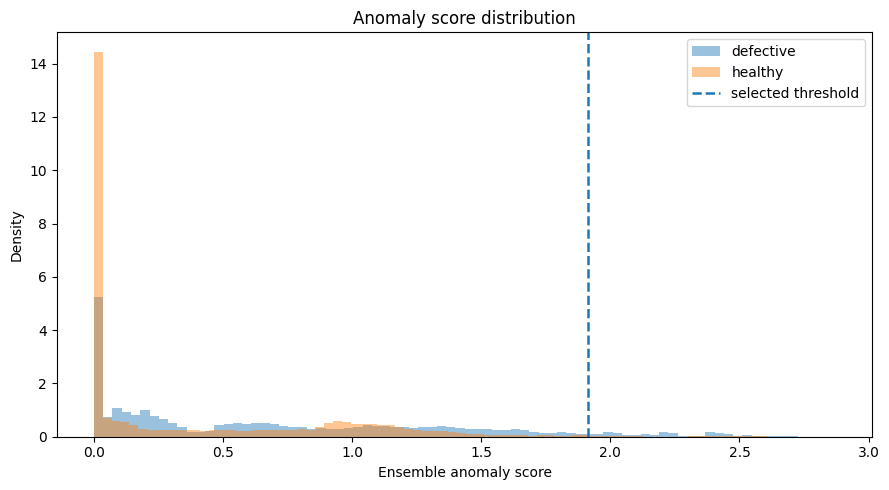

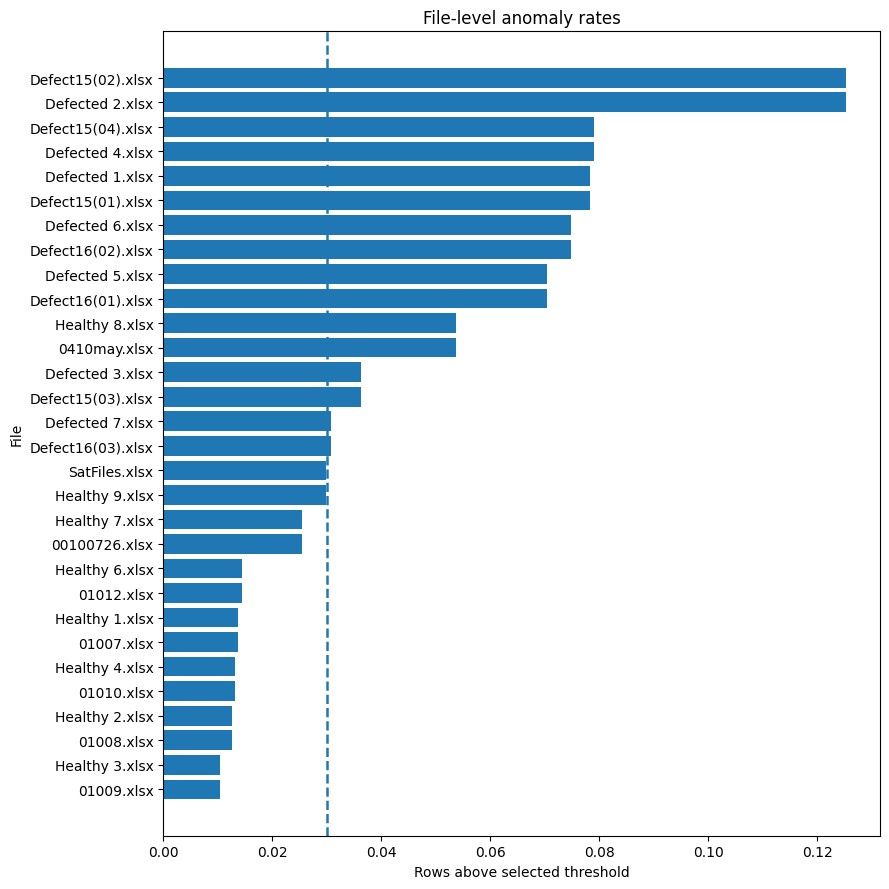

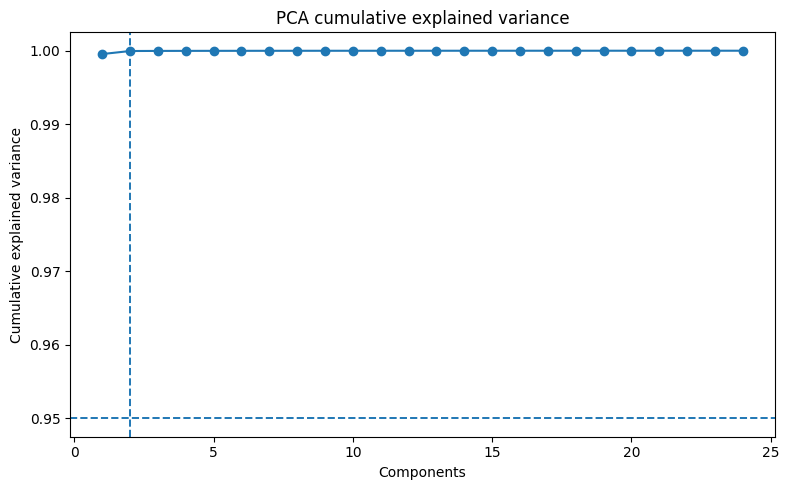

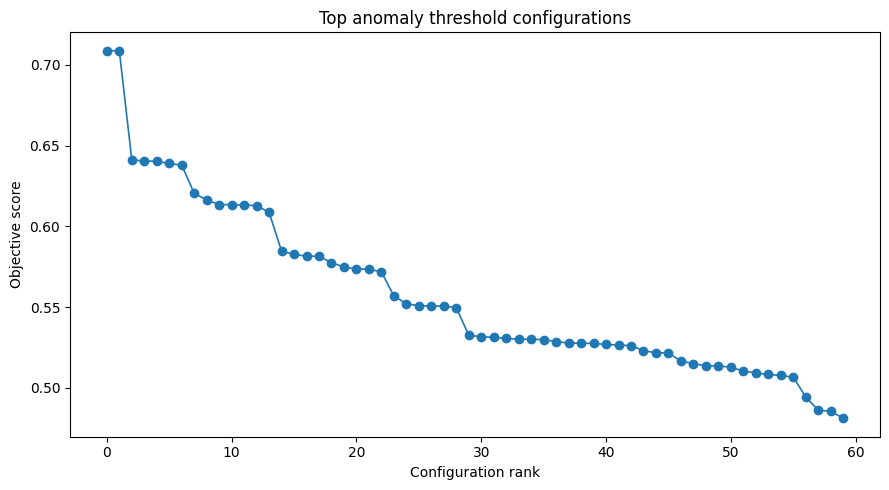

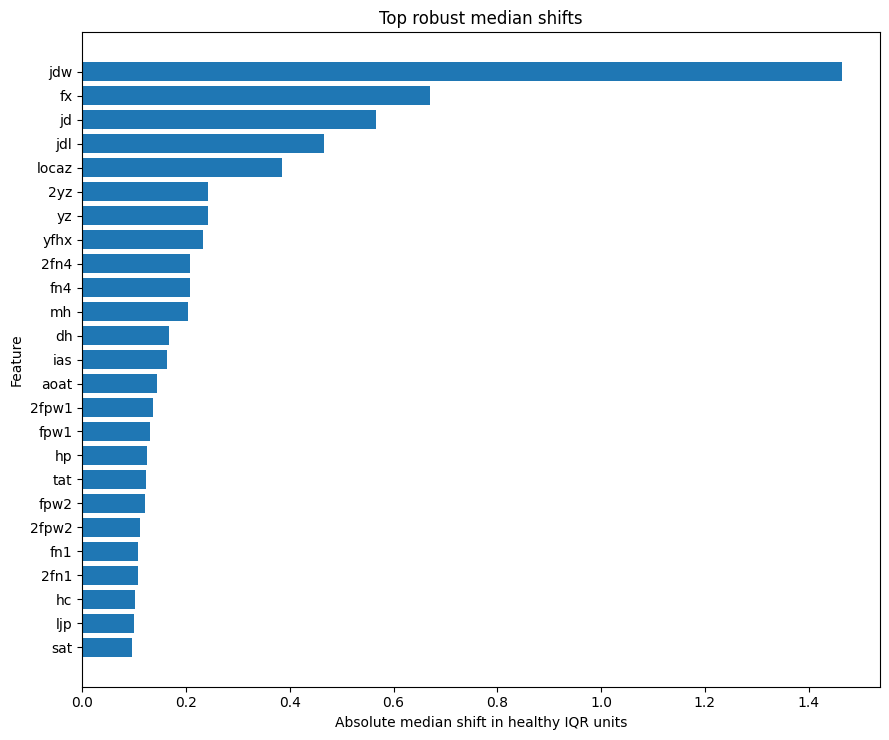

In [10]:
def save_current_figure(path):
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()


plt.figure(figsize=(9, 5))
for group_name, group_frame in standardized_df.groupby("group"):
    values = group_frame["ensemble_anomaly_score"].replace([np.inf, -np.inf], np.nan).dropna()
    if len(values):
        plt.hist(values, bins=80, alpha=0.45, density=True, label=group_name)
plt.axvline(best["threshold"], linestyle="--", linewidth=1.8, label="selected threshold")
plt.title("Anomaly score distribution")
plt.xlabel("Ensemble anomaly score")
plt.ylabel("Density")
plt.legend()
save_current_figure(figures_dir / "anomaly_score_distribution.png")

plot_table = file_anomaly_summary.sort_values("anomaly_rate", ascending=True).tail(30)
plt.figure(figsize=(9, max(5, 0.30 * len(plot_table))))
plt.barh(plot_table["file_name"], plot_table["anomaly_rate"])
plt.axvline(best["file_rate_threshold"], linestyle="--", linewidth=1.8)
plt.title("File-level anomaly rates")
plt.xlabel("Rows above selected threshold")
plt.ylabel("File")
save_current_figure(figures_dir / "file_level_anomaly_rates.png")

plt.figure(figsize=(8, 5))
plt.plot(pca_variance["component"], pca_variance["cumulative_explained_variance"], marker="o")
plt.axhline(0.95, linestyle="--", linewidth=1.4)
plt.axvline(n_components, linestyle="--", linewidth=1.4)
plt.title("PCA cumulative explained variance")
plt.xlabel("Components")
plt.ylabel("Cumulative explained variance")
save_current_figure(figures_dir / "pca_explained_variance.png")

plt.figure(figsize=(9, 5))
head_search = threshold_search.head(60).reset_index(drop=True)
plt.plot(np.arange(len(head_search)), head_search["objective"], marker="o", linewidth=1.2)
plt.title("Top anomaly threshold configurations")
plt.xlabel("Configuration rank")
plt.ylabel("Objective score")
save_current_figure(figures_dir / "anomaly_threshold_search.png")

feature_drift_rows = []
for feature in selected_features:
    healthy_values = standardized_df.loc[standardized_df["group"].eq("healthy"), feature].dropna()
    defective_values = standardized_df.loc[standardized_df["group"].eq("defective"), feature].dropna()
    if len(healthy_values) and len(defective_values):
        healthy_center = float(healthy_values.median())
        defective_center = float(defective_values.median())
        spread = float(healthy_values.quantile(0.75) - healthy_values.quantile(0.25))
        if spread <= 1e-12:
            spread = float(healthy_values.std()) if float(healthy_values.std()) > 1e-12 else 1.0
        feature_drift_rows.append({"feature": feature, "median_shift_robust_units": abs(defective_center - healthy_center) / spread})
feature_drift = pd.DataFrame(feature_drift_rows).sort_values("median_shift_robust_units", ascending=False)
feature_drift.to_csv(tables_dir / "top_feature_drift.csv", index=False)
if len(feature_drift):
    plot_drift = feature_drift.head(25).sort_values("median_shift_robust_units", ascending=True)
    plt.figure(figsize=(9, max(5, 0.30 * len(plot_drift))))
    plt.barh(plot_drift["feature"], plot_drift["median_shift_robust_units"])
    plt.title("Top robust median shifts")
    plt.xlabel("Absolute median shift in healthy IQR units")
    plt.ylabel("Feature")
    save_current_figure(figures_dir / "top_feature_drift.png")


In [11]:
anomaly_bundle = {
    "random_state": RANDOM_STATE,
    "project_root": str(project_root),
    "selected_features": selected_features,
    "feature_medians": feature_medians.to_dict(),
    "scaler": scaler,
    "pca": pca,
    "initial_pca_variance": pca_variance.to_dict(orient="records"),
    "isolation_model": isolation_model,
    "selected_threshold": float(best["threshold"]),
    "selected_file_rate_threshold": float(best["file_rate_threshold"]),
    "selected_weights": {"pca": float(best["w_pca"]), "isolation": float(best["w_iso"]), "mahalanobis": float(best["w_maha"])},
    "quality_summary": quality_summary.to_dict(orient="records"),
    "outputs": {
        "standardized_data": written_standardized_path,
        "anomaly_scores": written_anomaly_path,
        "feature_manifest": str(metadata_dir / "feature_manifest.csv"),
        "figures_dir": str(figures_dir),
        "tables_dir": str(tables_dir),
    },
}

with open(models_dir / "anomaly_detection_bundle.pkl", "wb") as handle:
    pickle.dump(anomaly_bundle, handle)

with open(metadata_dir / "anomaly_run_manifest.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "rows": int(len(standardized_df)),
            "files": int(standardized_df["file_name"].nunique()),
            "selected_features": int(len(selected_features)),
            "selected_threshold": float(best["threshold"]),
            "selected_file_rate_threshold": float(best["file_rate_threshold"]),
            "healthy_file_false_alarm_rate": float(best["healthy_file_false_alarm_rate"]),
            "defective_file_detection_rate": float(best["defective_file_detection_rate"]),
            "row_roc_auc": None if pd.isna(best["row_roc_auc"]) else float(best["row_roc_auc"]),
        },
        handle,
        indent=2,
    )

assert len(selected_features) >= 2
assert "ensemble_anomaly_score" in standardized_df.columns
assert standardized_df["file_name"].nunique() >= 2
print("Anomaly detection notebook completed successfully.")


Anomaly detection notebook completed successfully.
